In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/cleaned/cleaned_data.csv",
    parse_dates=["Date"]
)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  17049 non-null  object        
 1   Customer_ID               17049 non-null  object        
 2   Date                      17049 non-null  datetime64[ns]
 3   Age                       17049 non-null  int64         
 4   Gender                    17049 non-null  object        
 5   City                      17049 non-null  object        
 6   Product_Category          17049 non-null  object        
 7   Unit_Price                17049 non-null  float64       
 8   Quantity                  17049 non-null  int64         
 9   Discount_Amount           17049 non-null  float64       
 10  Total_Amount              17049 non-null  float64       
 11  Payment_Method            17049 non-null  object        
 12  Device_Type       

## RETURNING CUSTOMER

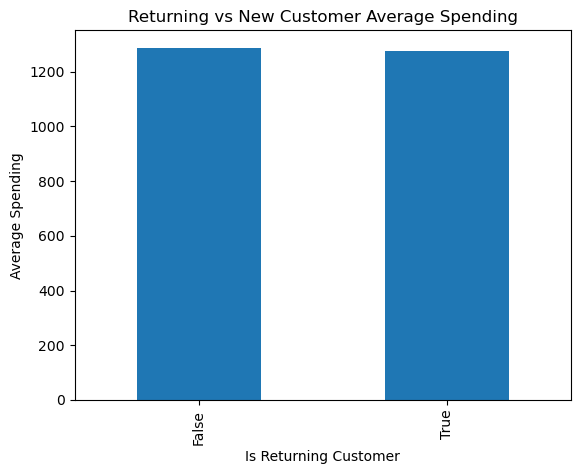

Is_Returning_Customer
False    1287.727428
True     1276.063599
Name: Total_Amount, dtype: float64

In [4]:
returning_mean = df.groupby(
    "Is_Returning_Customer"
)["Total_Amount"].mean()

returning_mean.plot(kind="bar")

plt.title(
    "Returning vs New Customer Average Spending"
)

plt.xlabel(
    "Is Returning Customer"
)

plt.ylabel(
    "Average Spending"
)

plt.show()

returning_mean

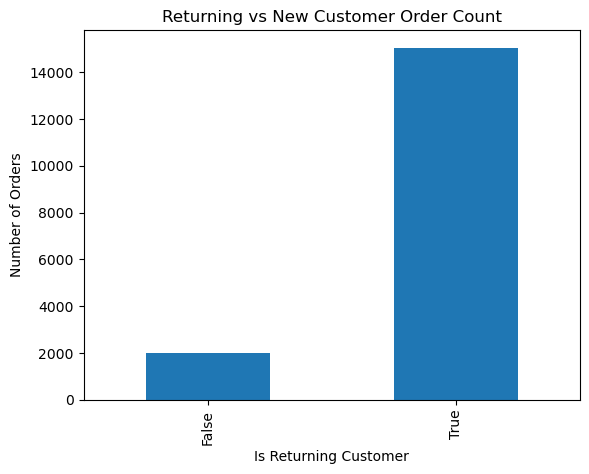

Is_Returning_Customer
False     2010
True     15039
Name: Order_ID, dtype: int64

In [5]:
returning_count = df.groupby(
    "Is_Returning_Customer"
)["Order_ID"].count()

returning_count.plot(kind="bar")

plt.title(
    "Returning vs New Customer Order Count"
)

plt.xlabel(
    "Is Returning Customer"
)

plt.ylabel(
    "Number of Orders"
)

plt.show()

returning_count

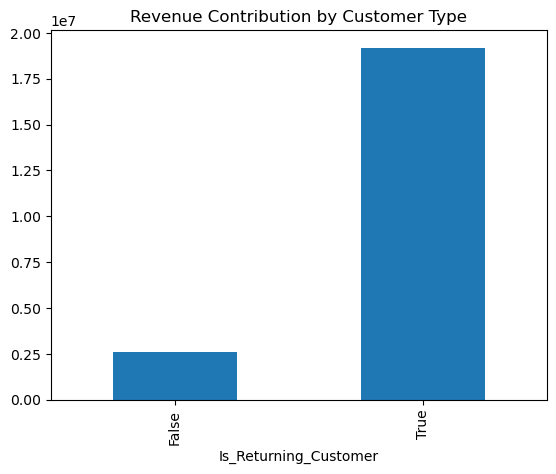

In [6]:
returning_revenue = df.groupby(
    "Is_Returning_Customer"
)["Total_Amount"].sum()

returning_revenue.plot(kind="bar")
plt.title("Revenue Contribution by Customer Type")
plt.show()

## CUSTOMER VALUE

In [7]:
customer_value = df.groupby(
    "Customer_ID"
)["Total_Amount"].sum()

top_customers = customer_value.sort_values(
    ascending=False
).head(10)

print(top_customers)

Customer_ID
CUST_01573    50628.15
CUST_00197    47324.23
CUST_03795    42480.02
CUST_00154    41613.83
CUST_04219    40608.39
CUST_03149    39834.61
CUST_03923    38610.82
CUST_01164    36842.41
CUST_01816    36557.27
CUST_04246    36295.30
Name: Total_Amount, dtype: float64


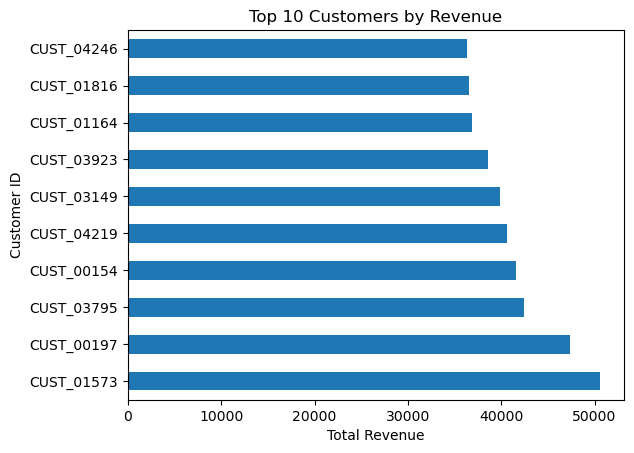

In [8]:
top_customers.plot(kind="barh")

plt.title(
    "Top 10 Customers by Revenue"
)

plt.xlabel(
    "Total Revenue"
)

plt.ylabel(
    "Customer ID"
)

plt.show()

In [9]:
total_revenue = customer_value.sum()

top10_revenue = top_customers.sum()

share = (
    top10_revenue
    /
    total_revenue
) * 100

print(share)

1.886193296528516


## Customer Lifetime Value (CLV)

## Customer Lifetime Value

In [10]:
clv = df.groupby("Customer_ID").agg({
    "Order_ID":"count",
    "Total_Amount":"sum"
})

clv.columns = [
    "Total_Orders",
    "Lifetime_Value"
]

clv.head()

,Total_Orders,Lifetime_Value
Customer_ID,,
CUST_00001,3,2199.63
CUST_00002,2,809.90
CUST_00003,2,3030.81
CUST_00004,1,383.22
CUST_00005,3,2422.73


## CLV Distribution

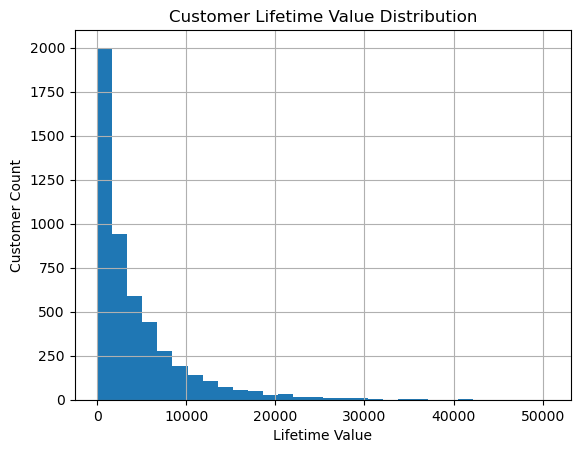

In [11]:
clv["Lifetime_Value"].hist(
    bins=30
)

plt.title(
    "Customer Lifetime Value Distribution"
)

plt.xlabel(
    "Lifetime Value"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

## VIP Customer Analysis

## VIP Customer Identification

In [12]:
vip = customer_value[
    customer_value >
    customer_value.quantile(0.9)
]

vip_count = pd.Series({
    "VIP": len(vip),
    "Normal":
    len(customer_value) - len(vip)
})

print(vip_count)

VIP        500
Normal    4500
dtype: int64


## VIP vs Normal Customers

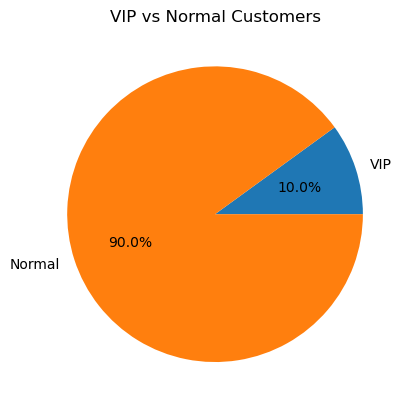

In [13]:
vip_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "VIP vs Normal Customers"
)

plt.ylabel("")

plt.show()

 ## VIP Revenue Contribution

In [14]:
vip_revenue = vip.sum()

total_revenue = customer_value.sum()

vip_share = (
    vip_revenue
    /
    total_revenue
) * 100

print(vip_share)

38.80785743582247


## RFM ANALYSIS

## Calculate RFM Metrics

In [15]:
latest_date = df["Date"].max()

rfm = df.groupby(
    "Customer_ID"
).agg({
    "Date":
    lambda x:
    (latest_date - x.max()).days,

    "Order_ID":"count",

    "Total_Amount":"sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST_00001,111,3,2199.63
CUST_00002,283,2,809.90
CUST_00003,82,2,3030.81
CUST_00004,41,1,383.22
CUST_00005,278,3,2422.73


## Recency vs Monetary

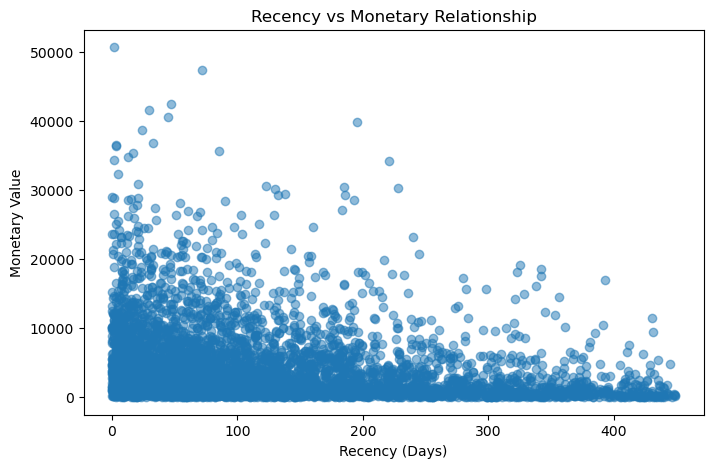

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    alpha=0.5
)

plt.title(
    "Recency vs Monetary Relationship"
)

plt.xlabel(
    "Recency (Days)"
)

plt.ylabel(
    "Monetary Value"
)

plt.show()

## RFM Distribution

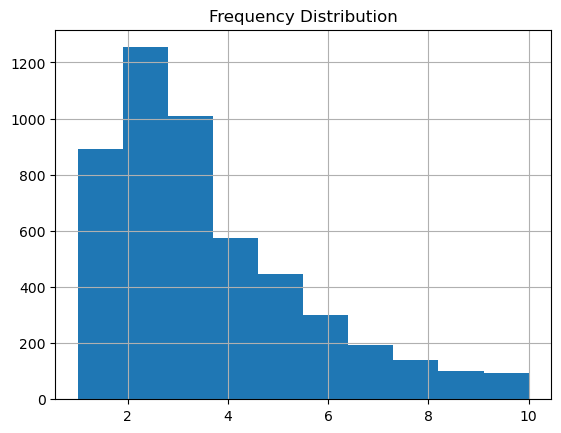

In [17]:
rfm["Frequency"].hist()

plt.title(
    "Frequency Distribution"
)

plt.show()

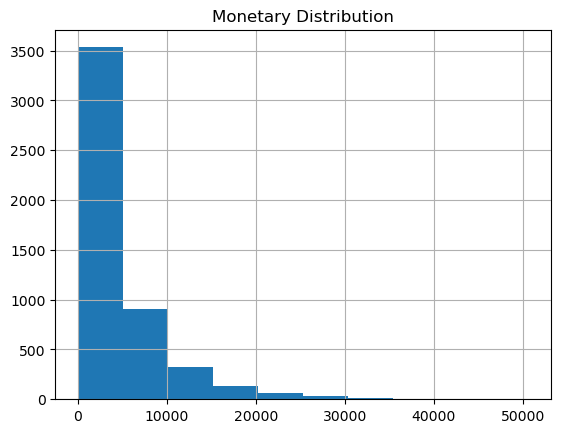

In [18]:
rfm["Monetary"].hist()

plt.title(
    "Monetary Distribution"
)

plt.show()

## RFM Scoring 

In [19]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(
        method="first"
    ),
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(
        method="first"
    ),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(
        method="first"
    ),
    5,
    labels=[1,2,3,4,5]
)

## RFM Segment Creation

In [20]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)

In [21]:
def segment_customer(row):

    if row["RFM_Score"] in [
        "555",
        "554",
        "545",
        "455"
    ]:
        return "Champions"

    elif row["RFM_Score"][1] == "5":
        return "Loyal Customers"

    elif row["RFM_Score"][2] == "5":
        return "Big Spenders"

    elif row["RFM_Score"][0] == "1":
        return "At Risk"

    else:
        return "Normal"

rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

## Segment Distribution

In [22]:
rfm["Segment"].value_counts()

Segment
Normal             2599
At Risk             920
Champions           540
Loyal Customers     517
Big Spenders        424
Name: count, dtype: int64

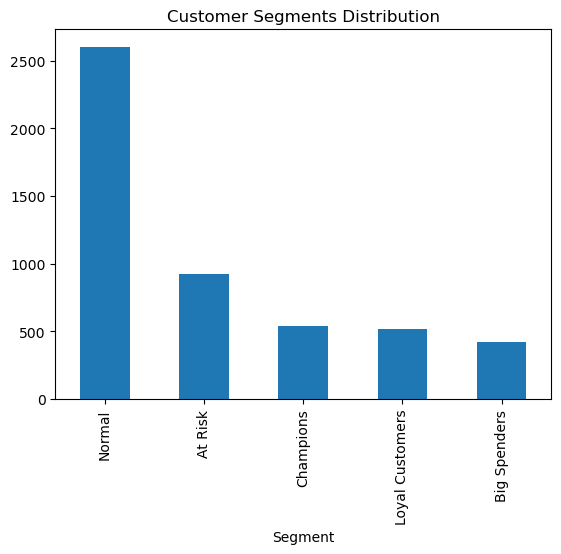

In [23]:
rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments Distribution"
)

plt.show()

## Segment Revenue Analysis

In [24]:
segment_revenue = rfm.groupby(
    "Segment"
)["Monetary"].sum()

segment_revenue

Segment
At Risk            1374740.36
Big Spenders       4994927.91
Champions          6270788.92
Loyal Customers    3487554.45
Normal             5651040.95
Name: Monetary, dtype: float64

In [25]:
segment_share = (
    segment_revenue /
    segment_revenue.sum()
) * 100

print(segment_share)

Segment
At Risk             6.312214
Big Spenders       22.934551
Champions          28.792753
Loyal Customers    16.013343
Normal             25.947139
Name: Monetary, dtype: float64


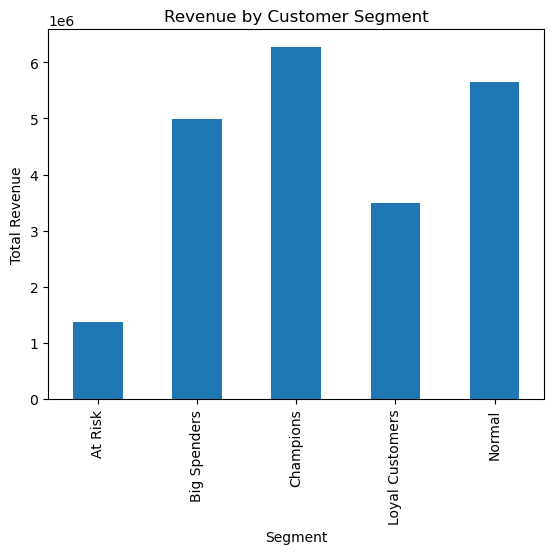

In [26]:
segment_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue by Customer Segment"
)

plt.ylabel(
    "Total Revenue"
)

plt.show()